# RF Model

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, r2_score

## Data Stuff

In [2]:
#BRING IN THE MOTHER
mother_file = pd.read_csv("data/one_hot_mama.csv")
#michelena test
#mother_file = pd.read_csv("data/mother_with_salaries.csv")
mother_file

# removing a ton of columns that are not helpful
# mother_file = mother_file.drop(columns=[col for col in mother_file.columns if 'waste_value_tonnes' in col])
# mother_file = mother_file.drop(columns=[col for col in mother_file.columns if 'capacity_value' in col])
# mother_file = mother_file.drop(columns=[col for col in mother_file.columns if 'waste_total_material' in col])
# mother_file = mother_file.drop(columns=[col for col in mother_file.columns if 'reserves_grade' in col])
# mother_file = mother_file.drop(columns=[col for col in mother_file.columns if 'reserves_mineral_value' in col])
# mother_file = mother_file.drop(columns=[col for col in mother_file.columns if 'reserves_commodity_value' in col])
# mother_file = mother_file.drop(columns=[col for col in mother_file.columns if 'commodities_grade' in col])
mother_file

,facility_id,primary_commodity,country,mining_salary,LOM_in_Buckets,still_operating,2000_Concentrate,2001_Concentrate,2002_Concentrate,2003_Concentrate,...,primary_commodity_Aluminium,primary_commodity_Coal,primary_commodity_Copper,primary_commodity_Gold,primary_commodity_Iron,primary_commodity_Nickel,primary_commodity_Other (poly)-metallic,primary_commodity_Other mine,primary_commodity_Silver,primary_commodity_Zinc
0,COM00003.00,Coal,United States of America,55819.00,47.0,1.0,NaN,NaN,NaN,NaN,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,COM00008.00,Nickel,Spain,37500.00,11.0,0.0,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,COM00009.00,Gold,Ghana,4509.60,15.0,1.0,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,COM00015.00,Copper,Kazakhstan,12877.81,6.0,1.0,NaN,NaN,NaN,NaN,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,COM00016.00,Gold,Ghana,4509.60,8.0,1.0,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
397,COM01415.00,Coal,Russian Federation,11616.07,68.0,1.0,NaN,NaN,NaN,NaN,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
398,COM01418.00,Gold,Tajikistan,2811.72,14.0,1.0,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
399,COM01419.00,Coal,China,19604.88,12.0,1.0,NaN,NaN,NaN,NaN,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
400,COM01430.00,Gold,China,19604.88,41.0,1.0,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
# Split on facility_id
facilities = mother_file["facility_id"].unique()
train_facilities, test_facilities = train_test_split(facilities, test_size=0.2, random_state=42)

train_df = mother_file[mother_file["facility_id"].isin(train_facilities)]
test_df  = mother_file[mother_file["facility_id"].isin(test_facilities)]

print(f"Train rows : {len(train_df)} ({len(train_facilities)} facilities)")
print(f"Test rows  : {len(test_df)} ({len(test_facilities)} facilities)")

# Extract target variable
y_train = train_df["LOM_in_Buckets"]
y_test  = test_df["LOM_in_Buckets"]
drop_cols = ["LOM_in_Buckets"]
# Drop unwanted columns (found after other data processing steps)to create feature matrices
X_train = train_df.drop(columns=drop_cols, errors="ignore").select_dtypes(include="number")
X_test  = test_df.drop(columns=drop_cols, errors="ignore").select_dtypes(include="number")

#we had a problem with infinite values accidentally :( 
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)

# Drop rows where target variable doesn't exist
mask_train = y_train.notna()
mask_test  = y_test.notna()
X_train, y_train = X_train[mask_train], y_train[mask_train]
X_test,  y_test  = X_test[mask_test],  y_test[mask_test]

# Fill NaNs in features with training median
X_train = X_train.fillna(X_train.median())
X_test  = X_test.fillna(X_train.median())

print(f"\nFeatures used : {list(X_train.columns)}")
print(f"Train samples : {len(X_train)}")
print(f"Test samples  : {len(X_test)}")

Train rows : 321 (321 facilities)
Test rows  : 81 (81 facilities)

Features used : ['mining_salary', 'still_operating', '2000_Concentrate', '2001_Concentrate', '2002_Concentrate', '2003_Concentrate', '2004_Concentrate', '2005_Concentrate', '2006_Concentrate', '2007_Concentrate', '2008_Concentrate', '2009_Concentrate', '2010_Concentrate', '2011_Concentrate', '2012_Concentrate', '2013_Concentrate', '2014_Concentrate', '2015_Concentrate', '2016_Concentrate', '2017_Concentrate', '2018_Concentrate', '2019_Concentrate', '2020_Concentrate', '2000_Ore processed', '2001_Ore processed', '2002_Ore processed', '2003_Ore processed', '2004_Ore processed', '2005_Ore processed', '2006_Ore processed', '2007_Ore processed', '2008_Ore processed', '2009_Ore processed', '2010_Ore processed', '2011_Ore processed', '2012_Ore processed', '2013_Ore processed', '2014_Ore processed', '2015_Ore processed', '2016_Ore processed', '2017_Ore processed', '2018_Ore processed', '2019_Ore processed', '2020_Ore processed'

# For Loop Different Feature Combinations

### Load in separate data file just for my For Loop Combinations and Other Data Processing desires

In [4]:
drop_bases = ['waste_total_material_tonnes', 'waste_value_tonnes', 'Ore processed']
for_loop_data = pd.read_csv('data/one_hot_mama.csv')
cols_to_drop = [
    col for col in for_loop_data.columns
    if any(col == base or col.endswith(f'_{base}') or col.startswith(f'{base}_') for base in drop_bases)
]
for_loop_data = for_loop_data.drop(columns=cols_to_drop, errors='ignore')
print(f'Dropped {len(cols_to_drop)} columns: {cols_to_drop}')
for_loop_data.to_csv('data/for_loop_data.csv', index=False)


Dropped 59 columns: ['2000_Ore processed', '2001_Ore processed', '2002_Ore processed', '2003_Ore processed', '2004_Ore processed', '2005_Ore processed', '2006_Ore processed', '2007_Ore processed', '2008_Ore processed', '2009_Ore processed', '2010_Ore processed', '2011_Ore processed', '2012_Ore processed', '2013_Ore processed', '2014_Ore processed', '2015_Ore processed', '2016_Ore processed', '2017_Ore processed', '2018_Ore processed', '2019_Ore processed', '2020_Ore processed', '2002_waste_total_material_tonnes', '2003_waste_total_material_tonnes', '2004_waste_total_material_tonnes', '2005_waste_total_material_tonnes', '2006_waste_total_material_tonnes', '2007_waste_total_material_tonnes', '2008_waste_total_material_tonnes', '2009_waste_total_material_tonnes', '2010_waste_total_material_tonnes', '2011_waste_total_material_tonnes', '2012_waste_total_material_tonnes', '2013_waste_total_material_tonnes', '2014_waste_total_material_tonnes', '2015_waste_total_material_tonnes', '2016_waste_t

## Create Total Commodities, Minerals, and Coal

In [5]:
# Combine coal_mined, commodities, and minerals_ore_mined production values
# Sum across all years for each facility_id
coal_cols = [col for col in for_loop_data.columns if 'coal_mined_value_tonnes' in col]
commodities_cols = [col for col in for_loop_data.columns if 'commodities_value_tonnes' in col]
commodities_cols_tot = [col for col in for_loop_data.columns if 'total_commodities' in col]
minerals_cols = [col for col in for_loop_data.columns if 'minerals_ore_mined_value_tonnes' in col]

for_loop_data['total_coal'] = for_loop_data[coal_cols].sum(axis=1)
for_loop_data['total_commodities'] = for_loop_data[commodities_cols].sum(axis=1)
for_loop_data['total_minerals'] = for_loop_data[minerals_cols].sum(axis=1)

# if commodities_cols_tot != 0.0:
#     for_loop_data['total_production_value'] = for_loop_data['total_coal'] + for_loop_data['total_commodities']
# else:
#     for_loop_data['total_production_value'] = for_loop_data['total_coal'] + for_loop_data['total_minerals']

# Drop all year-suffixed versions of these columns
cols_to_remove = [
    col for col in for_loop_data.columns
    if any(x in col for x in ['coal_mined_value_tonnes', 'commodities_value_tonnes', 'minerals_ore_mined_value_tonnes'])
]
for_loop_data = for_loop_data.drop(columns=cols_to_remove, errors='ignore')

# Move the combined features close to the front
combined_cols = ['total_production_value', 'total_commodities', 'total_minerals', 'total_coal']
cols = [c for c in for_loop_data.columns if c not in combined_cols]
insert_pos = 1 if 'facility_id' in cols else 0
for_loop_data = pd.concat([for_loop_data[[c for c in for_loop_data.columns if c in cols[:insert_pos] + combined_cols]],
                            for_loop_data[[c for c in for_loop_data.columns if c not in cols[:insert_pos] + combined_cols]]],
                           axis=1)

print(f"Created totals and removed {len(cols_to_remove)} year-based columns")
for_loop_data.to_csv('data/for_loop_data.csv', index=False)
print(f"Updated for_loop_data.csv with combined production values")


Created totals and removed 63 year-based columns
Updated for_loop_data.csv with combined production values


## Condense Reserves Mineral Value Tonnes, Avg Reserves Grade PPM, Reserves Commodity Value Tonnes, Commodity Recovery Rate, Avg Commodities Grade PPM

In [6]:
# Condense reserve and commodity summary columns across years
reserve_mineral_cols = [col for col in for_loop_data.columns if 'reserves_mineral_value_tonnes' in col]
reserve_commodity_cols = [col for col in for_loop_data.columns if 'reserves_commodity_value_tonnes' in col]
reserve_grade_cols = [col for col in for_loop_data.columns if 'reserves_grade_ppm' in col]
commodity_recovery_cols = [col for col in for_loop_data.columns if 'commodities_recovery_rate' in col]
commodity_grade_cols = [col for col in for_loop_data.columns if 'commodities_grade_ppm' in col]

for_loop_data['total_reserves_minerals'] = for_loop_data[reserve_mineral_cols].sum(axis=1)
for_loop_data['total_reserves_commodities'] = for_loop_data[reserve_commodity_cols].sum(axis=1)

# Average non-zero reserve grade ppm
if reserve_grade_cols:
    reserve_grade_nonzero = for_loop_data[reserve_grade_cols].replace(0, np.nan)
    reserve_grade_sum = reserve_grade_nonzero.sum(axis=1)
    reserve_grade_count = reserve_grade_nonzero.count(axis=1)
    for_loop_data['avg_reserves_grade_ppm'] = reserve_grade_sum / reserve_grade_count
else:
    for_loop_data['avg_reserves_grade_ppm'] = np.nan

# Average non-zero commodity recovery rate
if commodity_recovery_cols:
    recovery_nonzero = for_loop_data[commodity_recovery_cols].replace(0, np.nan)
    recovery_sum = recovery_nonzero.sum(axis=1)
    recovery_count = recovery_nonzero.count(axis=1)
    for_loop_data['avg_commodity_recovery_rate'] = recovery_sum / recovery_count
else:
    for_loop_data['avg_commodity_recovery_rate'] = np.nan

# Average non-zero commodities grade ppm
if commodity_grade_cols:
    grade_nonzero = for_loop_data[commodity_grade_cols].replace(0, np.nan)
    grade_sum = grade_nonzero.sum(axis=1)
    grade_count = grade_nonzero.count(axis=1)
    for_loop_data['avg_commodities_grade_ppm'] = grade_sum / grade_count
else:
    for_loop_data['avg_commodities_grade_ppm'] = np.nan

# Drop all year-based reserve/commodity columns
reserve_cols_to_remove = [
    col for col in for_loop_data.columns
    if any(x in col for x in [
        'reserves_mineral_value_tonnes',
        'reserves_commodity_value_tonnes',
        'reserves_grade_ppm',
        'commodities_recovery_rate',
        'commodities_grade_ppm'
    ])
    and not col.startswith('avg_')   # ← protect the averaged summary columns
    and not col.startswith('total_') # ← protect total_ cols too, just in case

]
for_loop_data = for_loop_data.drop(columns=reserve_cols_to_remove, errors='ignore')

# Move the condensed summary columns to the front
summary_cols = [
    'total_reserves_minerals',
    'total_reserves_commodities',
    'avg_reserves_grade_ppm',
    'avg_commodity_recovery_rate',
    'avg_commodities_grade_ppm'
]
front_cols = [col for col in summary_cols if col in for_loop_data.columns]
if 'facility_id' in for_loop_data.columns:
    cols = ['facility_id'] + front_cols + [c for c in for_loop_data.columns if c not in (['facility_id'] + front_cols)]
else:
    cols = front_cols + [c for c in for_loop_data.columns if c not in front_cols]
for_loop_data = for_loop_data[cols]

# Save the condensed dataset and report what was removed
print(f"Created reserve summaries and removed {len(reserve_cols_to_remove)} year-based reserve/commodity columns")
for_loop_data.to_csv('data/for_loop_data.csv', index=False)
print('Updated for_loop_data.csv with reserve/commodity summary columns')


Created reserve summaries and removed 93 year-based reserve/commodity columns
Updated for_loop_data.csv with reserve/commodity summary columns


## Run the Feature Combinations

### for original dataset

In [7]:
import re
from itertools import combinations

for_loop = pd.read_csv('data/for_loop_data.csv')


# Split the condensed dataset by facility_id so the model sees distinct facilities in train/test.
facilities = for_loop['facility_id'].unique()
train_facilities, test_facilities = train_test_split(facilities, test_size=0.2, random_state=42)

train_loop_df = for_loop[for_loop['facility_id'].isin(train_facilities)].reset_index(drop=True)
test_loop_df = for_loop[for_loop['facility_id'].isin(test_facilities)].reset_index(drop=True)

y_train_loop = train_loop_df['LOM_in_Buckets']
y_test_loop = test_loop_df['LOM_in_Buckets']

numeric_feature_cols = [
    col for col in for_loop.select_dtypes(include='number').columns
    if col not in {'LOM_in_Buckets', 'facility_id'}
]
feature_groups = {}
for col in numeric_feature_cols:
    group_name = base_feature_name(col)
    feature_groups.setdefault(group_name, []).append(col)

print(f"Found {len(feature_groups)} numeric feature groups")
for group_name, cols in sorted(feature_groups.items(), key=lambda item: (-len(item[1]), item[0])):
    print(f"{group_name}: {len(cols)} columns")

feature_group_names = sorted(feature_groups)


NameError: name 'base_feature_name' is not defined

In [8]:
import heapq

# Evaluate combinations of grouped feature sets using only the condensed feature groups.
feature_groups_to_use = [
    'country',
    'avg_commodities_grade_ppm',
    'avg_commodity_recovery_rate',
    'avg_reserves_grade_ppm',
    'mining_salary',
    'price_usd_tonne',
    'still_operating',
    'total_coal',
    'total_commodities',
    'total_minerals',
    'total_reserves_commodities',
    'total_reserves_minerals',
    'primary_commodity',
]

search_groups = [g for g in feature_groups_to_use if g in feature_group_names]
print(f"Searching combinations over {len(search_groups)} feature groups")

best_results = []
max_results = 20
for r in range(1, min(4, len(search_groups)) + 1):
    for combo in combinations(search_groups, r):
        selected_cols = [col for group in combo for col in feature_groups[group]]
        X_train_combo = train_loop_df[selected_cols].select_dtypes(include='number').copy()
        X_test_combo = test_loop_df[selected_cols].select_dtypes(include='number').copy()

        X_train_combo = X_train_combo.replace([np.inf, -np.inf], np.nan)
        X_test_combo = X_test_combo.replace([np.inf, -np.inf], np.nan)
        #print(f"Dataset contains infinite values: {X_train_combo.isin([np.inf, -np.inf]).any().any()}")

        model_combo = RandomForestRegressor(random_state=42, n_estimators=100)
        model_combo.fit(X_train_combo, y_train_loop)
        score = r2_score(y_test_loop, model_combo.predict(X_test_combo))

        record = {
            'feature_groups': combo,
            'num_columns': len(selected_cols),
            'r2_test': score,
        }

        if len(best_results) < max_results:
            heapq.heappush(best_results, (score, record))
        else:
            heapq.heappushpop(best_results, (score, record))

best_sorted = [record for score, record in sorted(best_results, key=lambda x: x[0], reverse=True)]
combo_df = pd.DataFrame(best_sorted)
print(combo_df.to_string(index=False))

# Save only the top results to keep the output file small.
combo_df.to_csv('data/feature_group_combo_results.csv', index=False)
print('Saved top 20 feature-group combo results to data/feature_group_combo_results.csv')

NameError: name 'feature_group_names' is not defined

In [ ]:
# Save the best model's training and test data
best_combo = best_sorted[0]['feature_groups']
best_combo_cols = [col for group in best_combo for col in feature_groups[group]]

X_train_best = train_loop_df[best_combo_cols].select_dtypes(include='number').copy()
X_test_best = test_loop_df[best_combo_cols].select_dtypes(include='number').copy()

X_train_best = X_train_best.replace([np.inf, -np.inf], np.nan)
X_test_best = X_test_best.replace([np.inf, -np.inf], np.nan)
X_train_best = X_train_best.fillna(X_train_best.median())
X_test_best = X_test_best.fillna(X_train_best.median())

y_train_best = y_train_loop
y_test_best = y_test_loop

# Save to CSV files
X_train_best.to_csv('data/best_X_train.csv', index=False)
X_test_best.to_csv('data/best_X_test.csv', index=False)
y_train_best.to_csv('data/best_y_train.csv', index=False)
y_test_best.to_csv('data/best_y_test.csv', index=False)

print(f"Saved best model data:")
print(f"  Best feature groups: {best_combo}")
print(f"  X_train shape: {X_train_best.shape}")
print(f"  X_test shape: {X_test_best.shape}")
print(f"  y_train shape: {y_train_best.shape}")
print(f"  y_test shape: {y_test_best.shape}")
print(f"  Best R^2: {best_sorted[0]['r2_test']}")

Saved best model data:
  Best feature groups: ('country', 'avg_commodity_recovery_rate', 'avg_reserves_grade_ppm', 'price_usd_tonne')
  X_train shape: (321, 49)
  X_test shape: (81, 49)
  y_train shape: (321,)
  y_test shape: (81,)
  Best R^2: 0.2295937843949215


# Plot For Loop Model

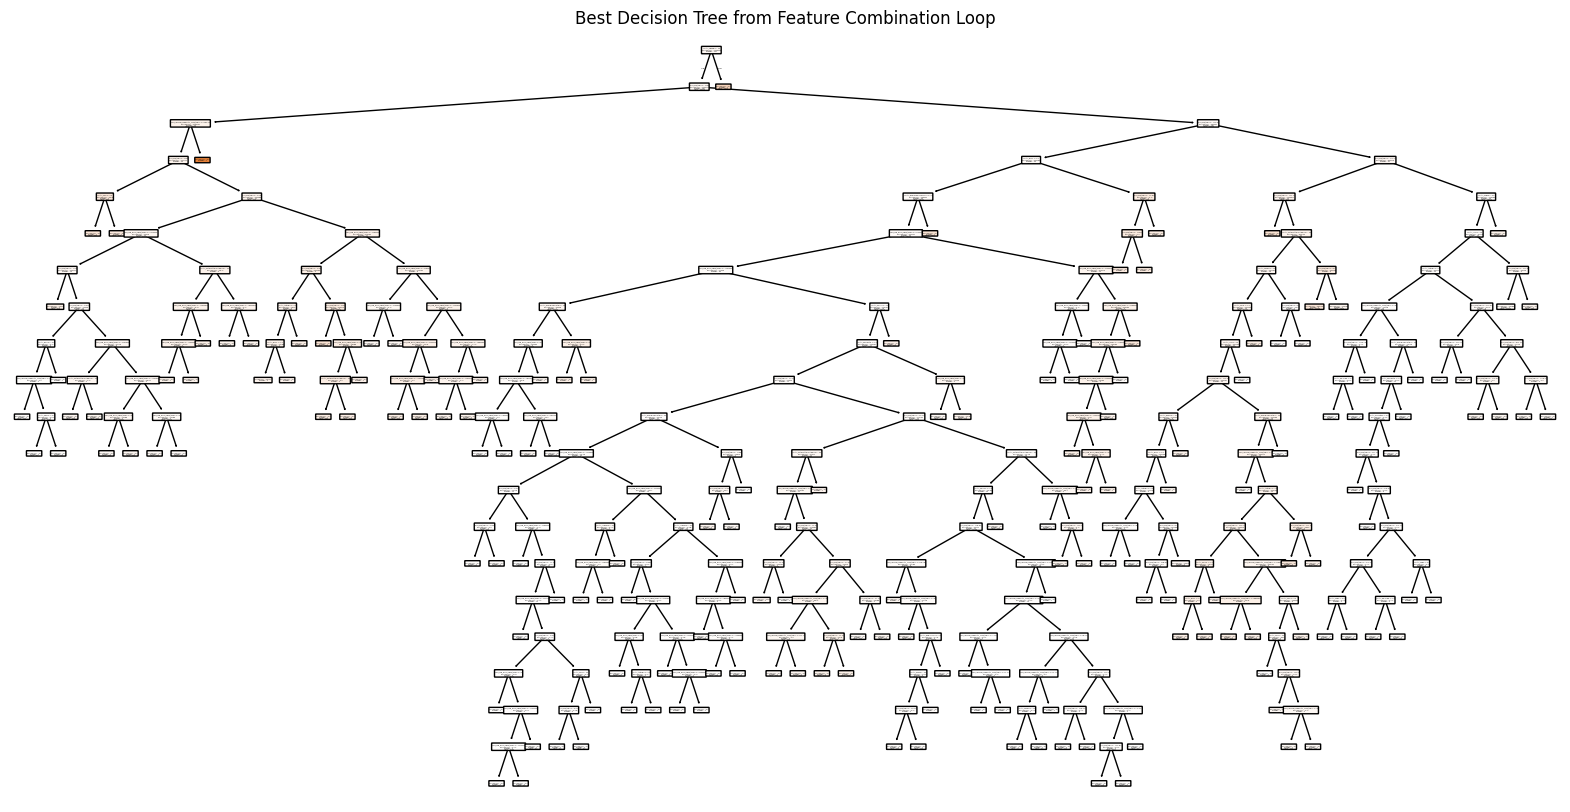

In [ ]:
# Plot the best decision tree from the feature combination loop
best_tree_model = RandomForestRegressor(random_state=42, n_estimators=100)
best_tree_model.fit(X_train_best, y_train_best)

best_tree = best_tree_model.estimators_[0]

plt.figure(figsize=(20,10)) 
plot_tree(best_tree,
          filled=True,              
          feature_names=X_train_best.columns.tolist(),
          rounded=True)             
plt.title("Best Decision Tree from Feature Combination Loop")
plt.show()


In [ ]:
# we're having some trouble with X, let's see what it is -- as it turns out, some values were infinite
#print(X_train)
pd.DataFrame(X_train).to_csv('data/X_train_check.csv', index=False)

# Base Model with Random Forest

In [ ]:
model = RandomForestRegressor()
model.fit(X_train, y_train)

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)
# print(y_pred_train)
# print(y_pred_test)

print('R^2 train:', r2_score(y_train, y_pred_train))
print('R^2 test :', r2_score(y_test, y_pred_test))

# accuracy_train_grid = accuracy_score(y_train, y_pred_train)
# accuracy_test_grid = accuracy_score(y_test, y_pred_test)


R^2 train: 0.8561904389349977
R^2 test : 0.11960996272527458


# Random Forest with Param Grid Attribute

In [ ]:
# # adapted from Pset 1 Q3 and Pset 3 Q3
param_grid = {
    'max_depth': (1, 3, 5, 10),
    'min_samples_leaf': (1, 5, 20)
    # 'criterion': (“squared_error”, “absolute_error”, “friedman_mse”, “poisson”)
}

tree = RandomForestRegressor()
grid_tree = GridSearchCV(estimator=tree,
                         param_grid=param_grid,
                         scoring='r2',
                         cv=5)

grid_tree.fit(X_train,y_train)
grid_model = grid_tree.best_estimator_

y_pred_train_grid = grid_model.predict(X_train)
y_pred_test_grid = grid_model.predict(X_test)

# accuracy_train_grid = accuracy_score(y_train, y_pred_train_grid)
# accuracy_test_grid = accuracy_score(y_test, y_pred_test_grid)

print("best accuracy", grid_tree.best_score_)
print("best params", grid_tree.best_params_)
print('Grid R^2 train:', r2_score(y_train, y_pred_train_grid))
print('Grid R^2 test :', r2_score(y_test, y_pred_test_grid))


# print(f'Train Accuracy = {accuracy_train_grid}')
# print(f'Test Accuracy = {accuracy_test_grid}')


best accuracy 0.1893052671109235
best params {'max_depth': 5, 'min_samples_leaf': 20}
Grid R^2 train: 0.23353436504313618
Grid R^2 test : 0.07969520893427429


# Plot the Random Forest with Best Param Grid Attributes (highest R^2)

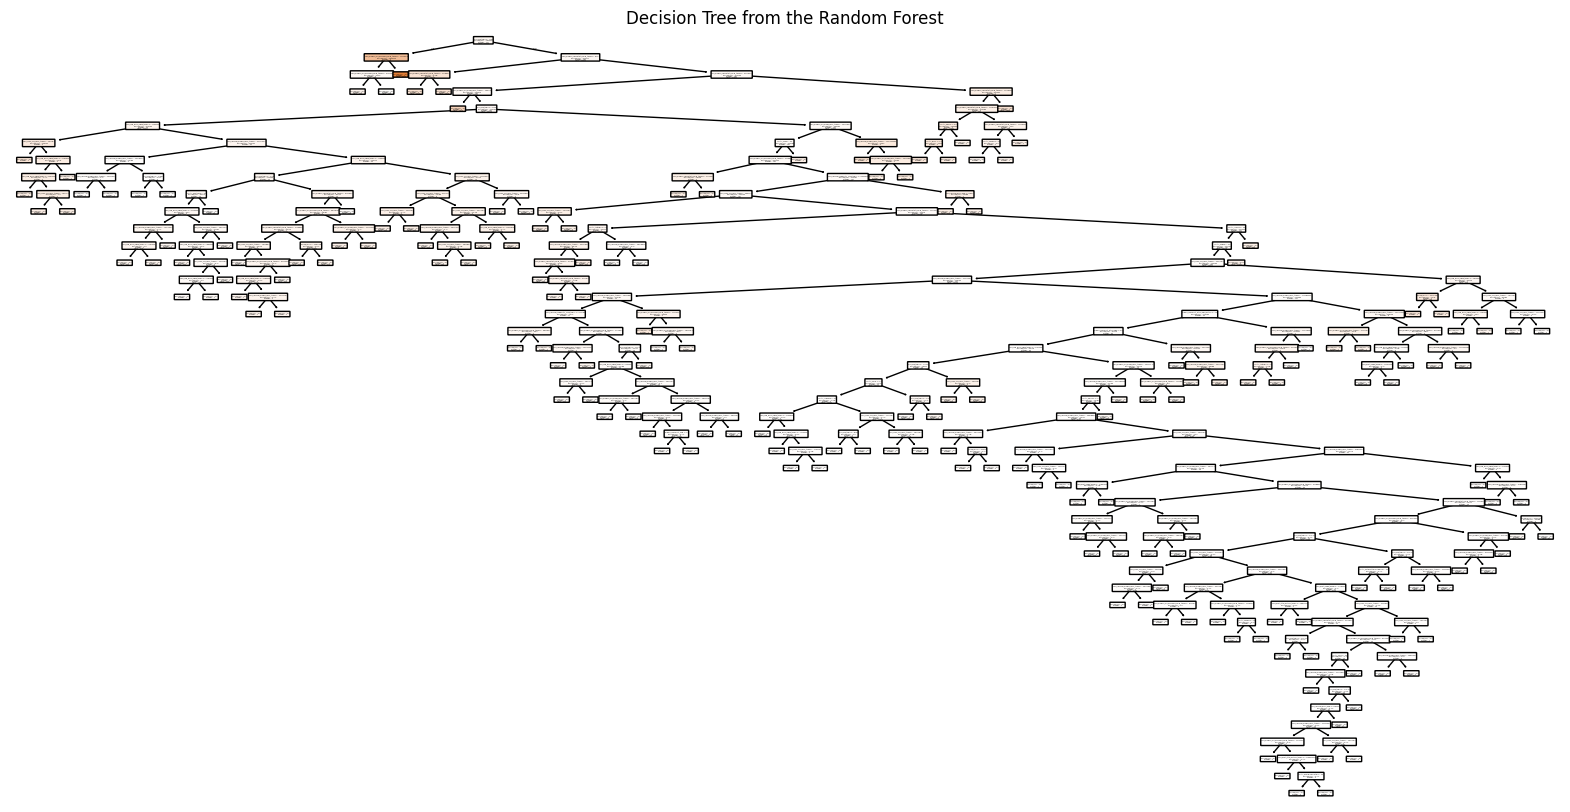

In [ ]:
tree = model.estimators_[0]

plt.figure(figsize=(20,10)) 
plot_tree(tree,
          filled=True,              
          feature_names=X_train.columns.tolist(),
          rounded=True)             # make things pretty
plt.title("Decision Tree from the Random Forest")
plt.show()

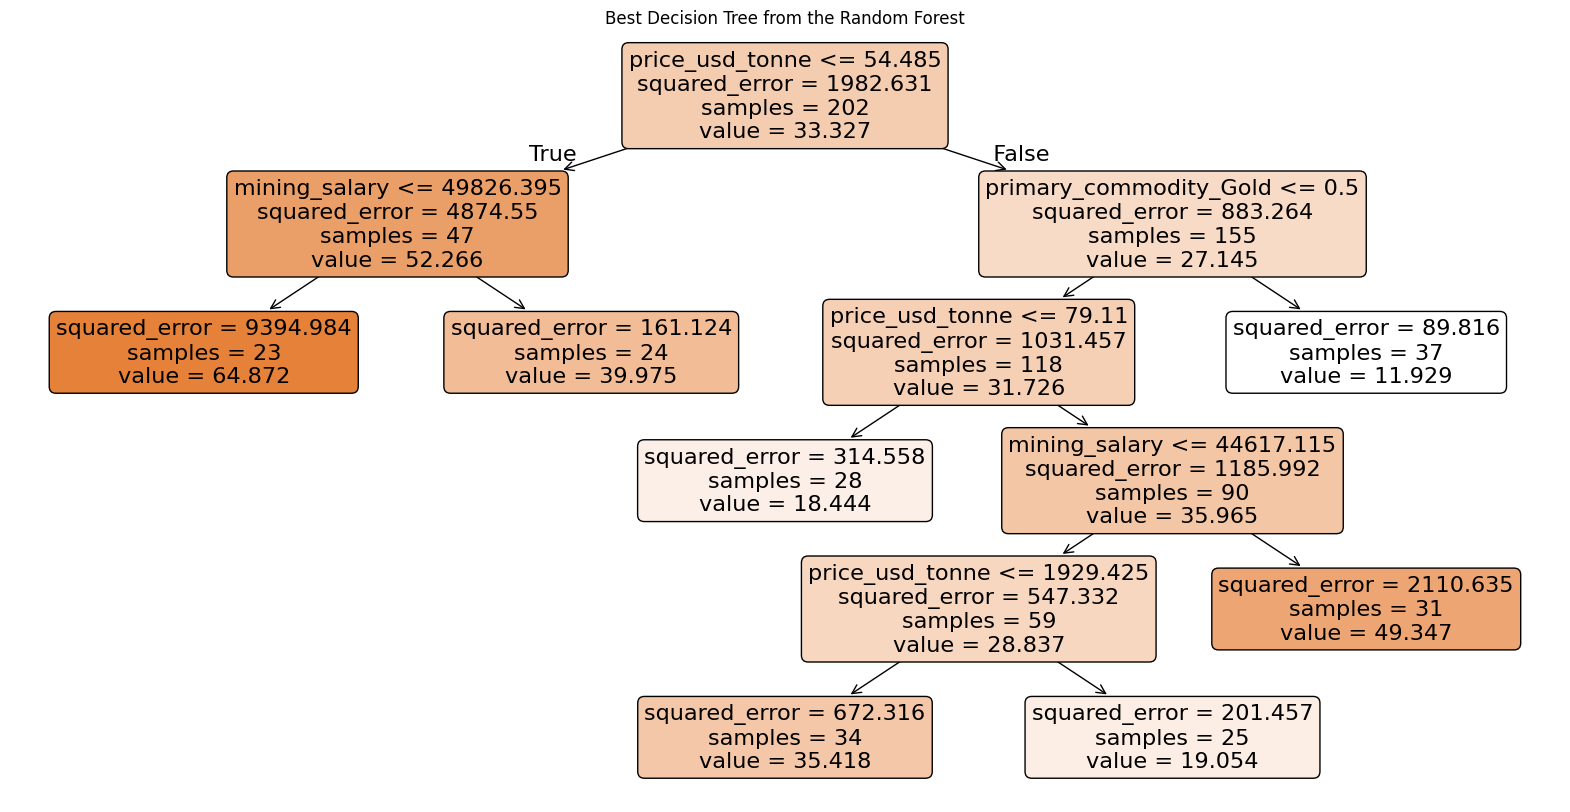

In [ ]:
grid_tree = grid_model.estimators_[0]

plt.figure(figsize=(20,10)) 
plot_tree(grid_tree,
          filled=True,              
          feature_names=X_train.columns.tolist(),
          rounded=True)             
plt.title("Best Decision Tree from the Random Forest")
plt.show()

# Open and Closed Mine Models

## Splitting Code on Still Open abd CLosed Mines

In [9]:
#separate data into rows with mine closure and mines without
df = pd.read_csv('data/for_loop_data.csv')

still_operating = df[df['still_operating'] == 1]
closed = df[df['still_operating'] == 0]

still_operating.to_csv('data/for_loop_data.csv', index=False)
closed.to_csv('data/for_loop_data_closed.csv', index=False)

print(f'Operating mines: {len(still_operating)} rows -> for_loop_data.csv')
print(f'Closed mines:    {len(closed)} rows -> for_loop_data_closed.csv')

Operating mines: 374 rows -> for_loop_data.csv
Closed mines:    28 rows -> for_loop_data_closed.csv


## Random Forest on Open Mines

In [10]:
# Split on facility_id
facilities = still_operating["facility_id"].unique()
train_facilities, test_facilities = train_test_split(facilities, test_size=0.2, random_state=42)

open_train_df = still_operating[still_operating["facility_id"].isin(train_facilities)]
open_test_df  = still_operating[still_operating["facility_id"].isin(test_facilities)]

print(f"Train rows : {len(open_train_df)} ({len(train_facilities)} facilities)")
print(f"Test rows  : {len(open_test_df)} ({len(test_facilities)} facilities)")

# Extract target variable
open_y_train = open_train_df["LOM_in_Buckets"]
open_y_test  = open_test_df["LOM_in_Buckets"]
drop_cols = ["LOM_in_Buckets"]
# Drop unwanted columns (found after other data processing steps)to create feature matrices
open_X_train = open_train_df.drop(columns=drop_cols, errors="ignore").select_dtypes(include="number")
open_X_test  = open_test_df.drop(columns=drop_cols, errors="ignore").select_dtypes(include="number")

#we had a problem with infinite values accidentally :( 
open_X_train = open_X_train.replace([np.inf, -np.inf], np.nan)
open_X_test = open_X_test.replace([np.inf, -np.inf], np.nan)

# Drop rows where target variable doesn't exist
mask_train = open_y_train.notna()
mask_test  = open_y_test.notna()
open_X_train, open_y_train = open_X_train[mask_train], open_y_train[mask_train]
open_X_test,  open_y_test  = open_X_test[mask_test],  open_y_test[mask_test]

# Fill NaNs in features with training median
open_X_train = open_X_train.fillna(open_X_train.median())
open_X_test  = open_X_test.fillna(open_X_train.median())

Train rows : 299 (299 facilities)
Test rows  : 75 (75 facilities)


In [11]:
open_model = RandomForestRegressor()
open_model.fit(open_X_train, open_y_train)

open_y_pred_train = open_model.predict(open_X_train)
open_y_pred_test  = open_model.predict(open_X_test)

print('R^2 train:', r2_score(open_y_train, open_y_pred_train))
print('R^2 test :', r2_score(open_y_test,  open_y_pred_test))

R^2 train: 0.8814049004840236
R^2 test : -0.5418254251693837


In [12]:
# adapted from Pset 1 Q3 and Pset 3 Q3
param_grid = {
    'max_depth': (1, 3, 5, 10),
    'min_samples_leaf': (1, 5, 20)
    # 'criterion': (“squared_error”, “absolute_error”, “friedman_mse”, “poisson”)
}

open_tree = RandomForestRegressor()
open_grid_tree = GridSearchCV(estimator=open_tree,
                         param_grid=param_grid,
                         scoring='r2',
                         cv=5)

open_grid_tree.fit(open_X_train, open_y_train)
open_grid_model = open_grid_tree.best_estimator_

y_pred_train_grid = open_grid_model.predict(open_X_train)
y_pred_test_grid = open_grid_model.predict(open_X_test)

print("best accuracy", open_grid_tree.best_score_)
print("best params", open_grid_tree.best_params_)
print('Grid R^2 train:', r2_score(open_y_train, y_pred_train_grid))
print('Grid R^2 test :', r2_score(open_y_test, y_pred_test_grid))

best accuracy 0.16895380417955047
best params {'max_depth': 10, 'min_samples_leaf': 5}
Grid R^2 train: 0.41011765535190314
Grid R^2 test : 0.2852588172697633


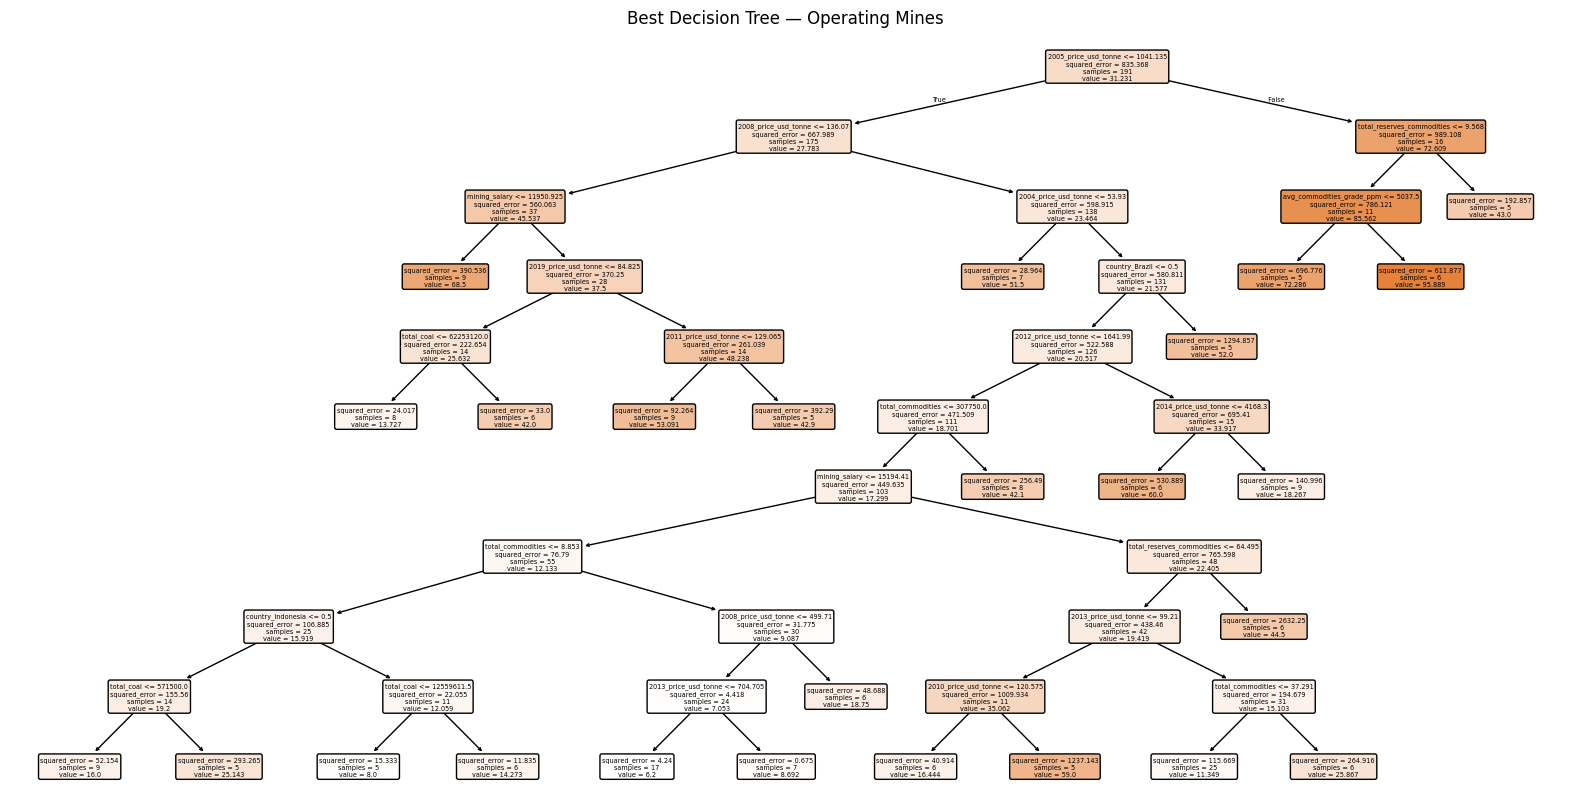

In [13]:
open_best_tree = open_grid_model.estimators_[0]

plt.figure(figsize=(20, 10))
plot_tree(open_best_tree,
          filled=True,
          feature_names=open_X_train.columns.tolist(),
          rounded=True)
plt.title('Best Decision Tree — Operating Mines')
plt.show()

## Random Forest on Closed Mines

In [14]:
# Same model as above but run with alternative file
# Split on facility_id
facilities = closed["facility_id"].unique()
train_facilities, test_facilities = train_test_split(facilities, test_size=0.2, random_state=42)

closed_train_df = closed[closed["facility_id"].isin(train_facilities)]
closed_test_df  = closed[closed["facility_id"].isin(test_facilities)]

print(f"Train rows : {len(closed_train_df)} ({len(train_facilities)} facilities)")
print(f"Test rows  : {len(closed_test_df)} ({len(test_facilities)} facilities)")

# Extract target variable
closed_y_train = closed_train_df["LOM_in_Buckets"]
closed_y_test  = closed_test_df["LOM_in_Buckets"]
drop_cols = ["LOM_in_Buckets"]
# Drop unwanted columns (found after other data processing steps)to create feature matrices
closed_X_train = closed_train_df.drop(columns=drop_cols, errors="ignore").select_dtypes(include="number")
closed_X_test  = closed_test_df.drop(columns=drop_cols, errors="ignore").select_dtypes(include="number")

#we had a problem with infinite values accidentally :( 
closed_X_train = closed_X_train.replace([np.inf, -np.inf], np.nan)
closed_X_test = closed_X_test.replace([np.inf, -np.inf], np.nan)

# Drop rows where target variable doesn't exist
mask_train = closed_y_train.notna()
mask_test  = closed_y_test.notna()
closed_X_train, closed_y_train = closed_X_train[mask_train], closed_y_train[mask_train]
closed_X_test,  closed_y_test  = closed_X_test[mask_test],  closed_y_test[mask_test]

# Fill NaNs in features with training median
closed_X_train = closed_X_train.fillna(closed_X_train.median())
closed_X_test  = closed_X_test.fillna(closed_X_train.median())

Train rows : 22 (22 facilities)
Test rows  : 6 (6 facilities)


In [15]:
closed_model = RandomForestRegressor()
closed_model.fit(closed_X_train, closed_y_train)

closed_y_pred_train = closed_model.predict(closed_X_train)
closed_y_pred_test  = closed_model.predict(closed_X_test)

print('R^2 train:', r2_score(closed_y_train, closed_y_pred_train))
print('R^2 test :', r2_score(closed_y_test,  closed_y_pred_test))

R^2 train: 0.8919474395160374
R^2 test : -1.9407290492159879


In [16]:
param_grid = {
    'max_depth': (1, 3, 5, 10),
    'min_samples_leaf': (1, 5, 20)
    # 'criterion': (“squared_error”, “absolute_error”, “friedman_mse”, “poisson”)
}

closed_tree = RandomForestRegressor()
closed_grid_tree = GridSearchCV(estimator=closed_tree,
                         param_grid=param_grid,
                         scoring='r2',
                         cv=5)

closed_grid_tree.fit(closed_X_train, closed_y_train)
closed_grid_model = closed_grid_tree.best_estimator_

y_pred_train_grid = closed_grid_model.predict(closed_X_train)
y_pred_test_grid = closed_grid_model.predict(closed_X_test)

print("best accuracy", closed_grid_tree.best_score_)
print("best params", closed_grid_tree.best_params_)
print('Grid R^2 train:', r2_score(closed_y_train, y_pred_train_grid))
print('Grid R^2 test :', r2_score(closed_y_test, y_pred_test_grid))

best accuracy -1.636814362989739
best params {'max_depth': 5, 'min_samples_leaf': 1}
Grid R^2 train: 0.8273042078801728
Grid R^2 test : -1.919470299898995


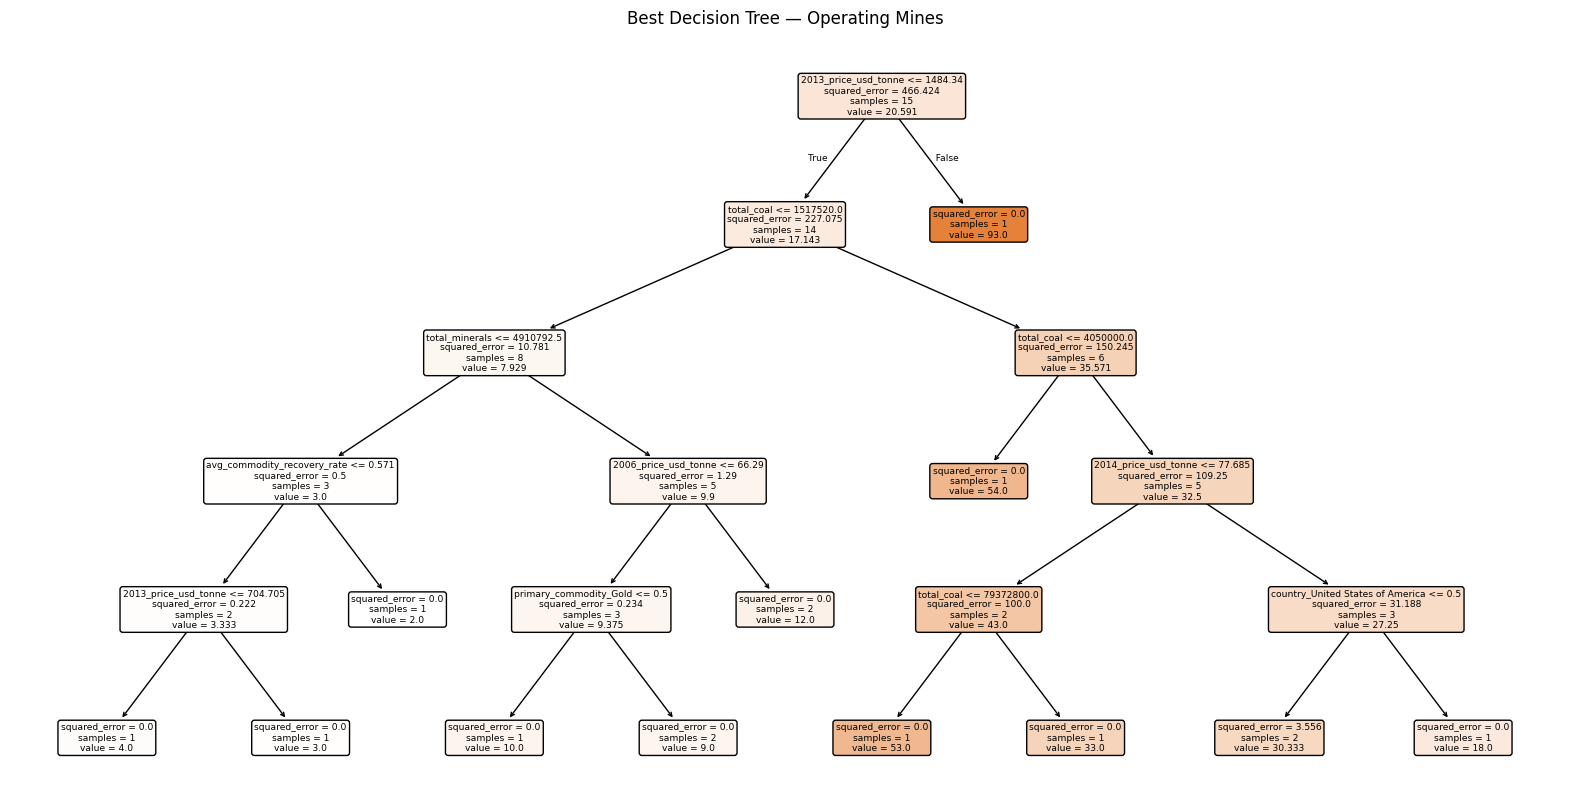

In [17]:
closed_best_tree = closed_grid_model.estimators_[0]

plt.figure(figsize=(20, 10))
plot_tree(closed_best_tree,
          filled=True,
          feature_names=closed_X_train.columns.tolist(),
          rounded=True)
plt.title('Best Decision Tree — Operating Mines')
plt.show()

# Begin Evaluations